# Tarea 2 
### Fernando Navarro Arias 

2022430320


fnavarro2022@udec.cl


## 0. Librerías

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import missingno as msno
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

---
## Pregunta 1: Carga, exploración, estadísticas descriptivas y limpieza

### 1.1 Carga de datos e identificacion de tipos

In [135]:
df1 = pd.read_csv('dataset_prueba.csv')
df  = df1.copy()
df.dtypes

iso_code                                               object
date                                                   object
retail_and_recreation_percent_change_from_baseline    float64
grocery_and_pharmacy_percent_change_from_baseline     float64
parks_percent_change_from_baseline                    float64
transit_stations_percent_change_from_baseline         float64
workplaces_raw                                        float64
residential_percent_change_from_baseline              float64
trend                                                 float64
workplaces                                            float64
Valor_Stringency_Index                                float64
Valor_GovernmentResponseIndex                         float64
Valor_EconomicSupportIndex                            float64
Valor_Containment_Health_index                        float64
workplace_closing                                     float64
daily_cases                                           float64
d2      

In [136]:
print(f'Dimensiones: {df.shape}')
print(f'Ciudades únicas: {df["iso_code"].nunique()}')
print(f'Rango temporal: {df["date"].min()} a {df["date"].max()}')
df.head()

Dimensiones: (12040, 41)
Ciudades únicas: 54
Rango temporal: 2020-02-17 a 2022-10-17


,iso_code,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_raw,residential_percent_change_from_baseline,trend,workplaces,...,edu3,age_dependency,old_age_dependency,young_age_dependency,sex_ratio,unemp,f_unemp,m_unemp,foreigners,country
0,DE-BE,2020-02-17,6.0,3.0,15.0,4.0,1.0,0.0,9.266668,4.244073,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
1,DE-BE,2020-02-24,1.6,0.0,8.6,0.0,0.2,0.6,5.006175,2.468286,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
2,DE-BE,2020-03-02,2.6,6.4,8.2,-0.4,0.4,1.0,-3.765428,-2.845394,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
3,DE-BE,2020-03-09,-3.4,3.4,-1.0,-5.8,-0.6,1.8,-12.537031,-11.510297,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
4,DE-BE,2020-03-16,-11.8,11.4,-4.6,-16.0,-7.8,4.6,-21.308634,-21.800890,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE


### 1.2 Valores faltantes en datos originales

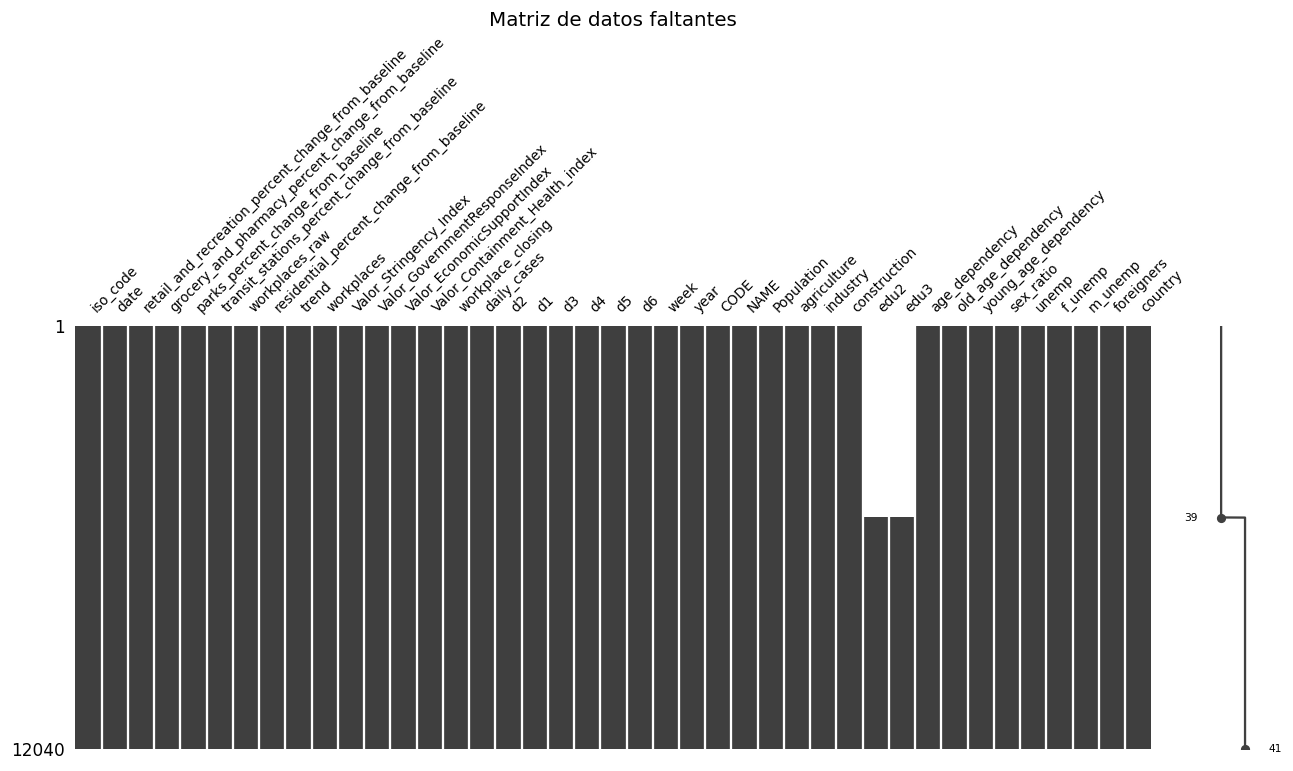

In [137]:
msno.matrix(df, figsize=(14, 5), fontsize=9)
plt.title('Matriz de datos faltantes', fontsize=13)
plt.show()

In [138]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Faltantes': missing, '% Faltantes': missing_pct})
missing_df[missing_df['Faltantes'] > 0].sort_values('% Faltantes', ascending=False)

,Faltantes,% Faltantes
edu2,5460,45.35
edu3,5460,45.35


**Observación:** `edu2` y `edu3` concentran ~45% de missings. Se eliminarán por su alto porcentaje de datos faltantes. Las demás variables clave no presentan valores faltantes.

### 1.3 Limpieza de variables

In [139]:
# Convertir date a datetime
df['date'] = pd.to_datetime(df['date'])

# Eliminar variables con demasiados faltantes
cols_drop = [c for c in df.columns if df[c].isnull().mean() > 0.40]
print(f'Variables eliminadas (>40% faltantes): {cols_drop}')
df = df.drop(columns=cols_drop)

# Eliminar filas con faltantes en variables clave
key_vars = ['workplaces', 'Valor_Stringency_Index', 'workplace_closing', 'daily_cases']
n_before = len(df)
df = df.dropna(subset=key_vars)
print(f'Filas eliminadas: {n_before - len(df)}')
print(f'Dimensiones finales: {df.shape}')

Variables eliminadas (>40% faltantes): ['edu2', 'edu3']
Filas eliminadas: 0
Dimensiones finales: (12040, 39)


In [140]:
# Verificar balance del panel
panel_balance = df.groupby('iso_code')['date'].count()
print(f'Obs por ciudad — Min: {panel_balance.min()}, Max: {panel_balance.max()}, Media: {panel_balance.mean():.1f}')
print(f'Panel balanceado: {panel_balance.nunique() == 1}')
panel_balance.value_counts().sort_index()

Obs por ciudad — Min: 140, Max: 2100, Media: 223.0
Panel balanceado: False


date
140     42
280      5
420      5
560      1
2100     1
Name: count, dtype: int64

### 1.4 Estadísticas descriptivas

In [141]:
vars_interes = [
    'workplaces', 'workplaces_raw',
    'Valor_Stringency_Index', 'Valor_GovernmentResponseIndex',
    'Valor_Containment_Health_index', 'workplace_closing',
    'daily_cases', 'residential_percent_change_from_baseline',
    'retail_and_recreation_percent_change_from_baseline',
    'transit_stations_percent_change_from_baseline',
    'Population', 'unemp', 'age_dependency', 'foreigners'
]
vars_interes = [v for v in vars_interes if v in df.columns]
df[vars_interes].describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
workplaces,12040.0,-18.667,11.801,-76.787,-24.358,-16.820,-10.884,19.058
workplaces_raw,12040.0,-25.003,14.681,-87.000,-32.400,-22.800,-14.400,6.600
Valor_Stringency_Index,12040.0,27.486,29.836,0.000,0.000,15.858,53.420,93.520
Valor_GovernmentResponseIndex,12040.0,30.637,30.245,0.000,0.000,32.030,60.160,81.306
Valor_Containment_Health_index,12040.0,30.592,29.943,0.000,0.000,36.610,59.230,85.420
workplace_closing,12040.0,0.851,0.997,0.000,0.000,0.000,2.000,3.000
daily_cases,12040.0,2355.733,3154.914,0.000,0.037,632.010,3815.644,22203.314
residential_percent_change_from_baseline,12040.0,7.071,6.023,-3.800,3.200,5.600,9.400,42.600
retail_and_recreation_percent_change_from_baseline,12040.0,-16.437,21.599,-95.600,-26.400,-11.400,-3.600,74.600
transit_stations_percent_change_from_baseline,12040.0,-17.602,24.541,-88.600,-31.800,-18.400,-4.400,123.200


### 1.5 Distribuciones y detección de outliers

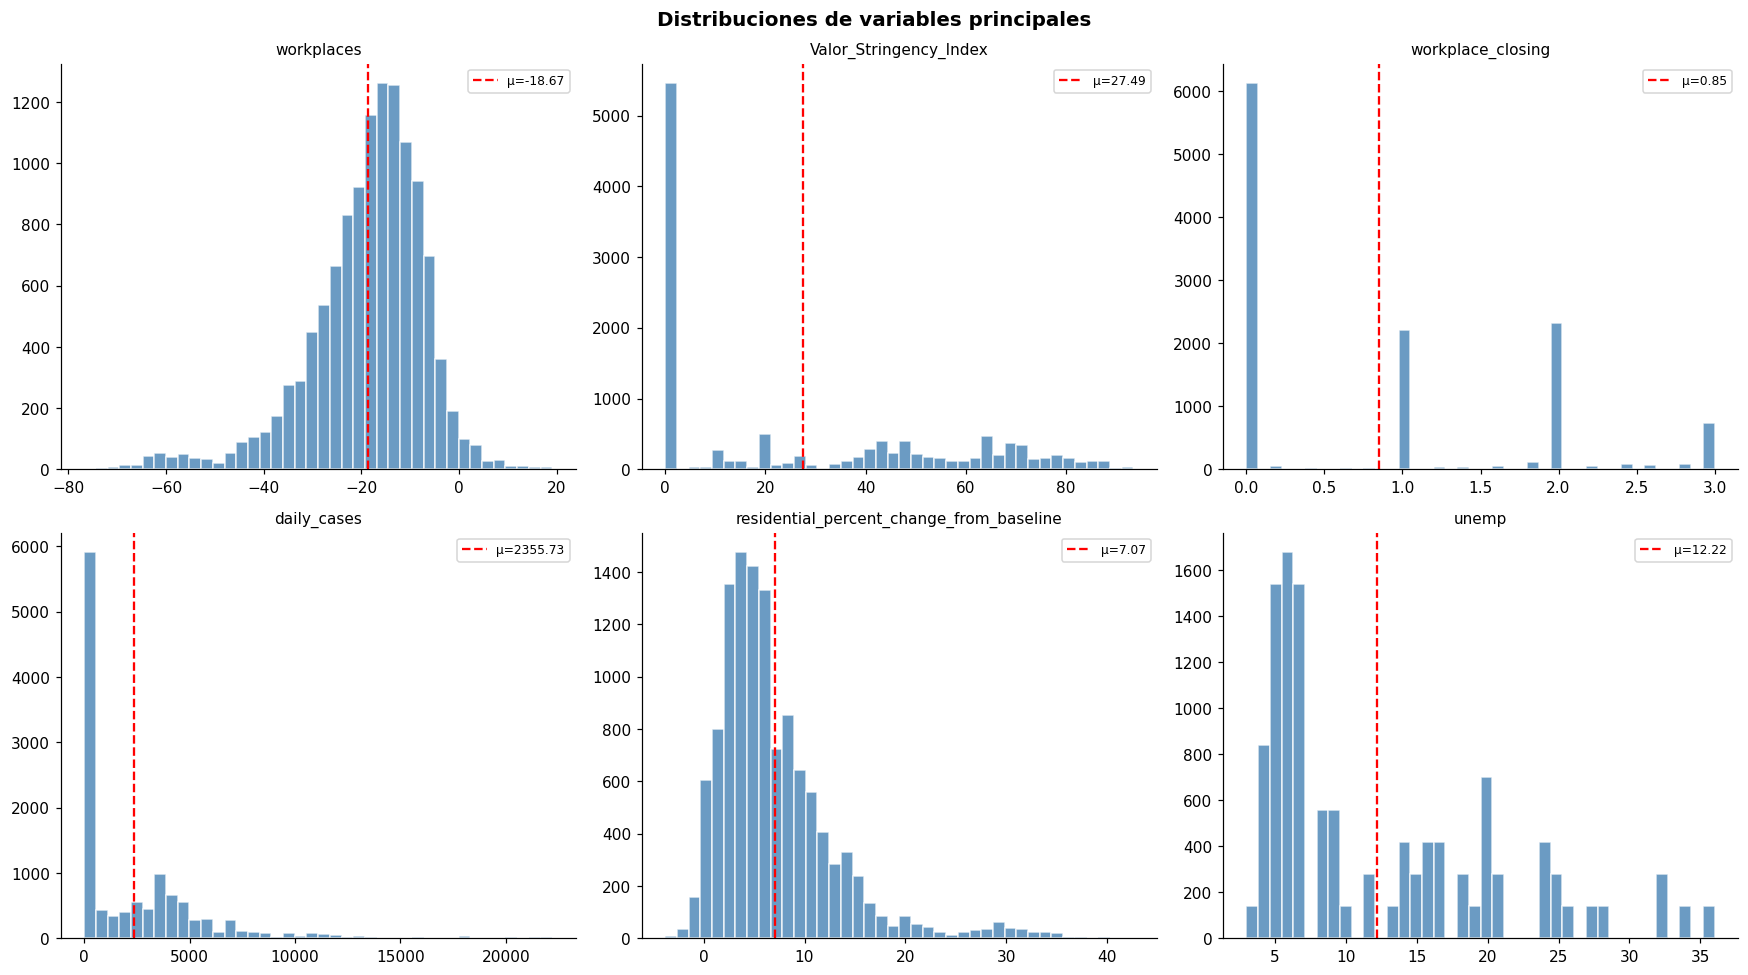

In [142]:
plot_vars = ['workplaces', 'Valor_Stringency_Index', 'workplace_closing',
             'daily_cases', 'residential_percent_change_from_baseline', 'unemp']
plot_vars = [v for v in plot_vars if v in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, var in enumerate(plot_vars):
    ax = axes.flatten()[i]
    ax.hist(df[var].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df[var].mean(), color='red', ls='--', label=f'μ={df[var].mean():.2f}')
    ax.set_title(var, fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle('Distribuciones de variables principales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observación a los histogramas:** Las variables de movilidad y casos diarios presentan distribuciones asimétricas (sesgadas), mientras que los índices de restricción tienen colas largas o distribuciones multimodales dependiendo de las etapas de la pandemia.

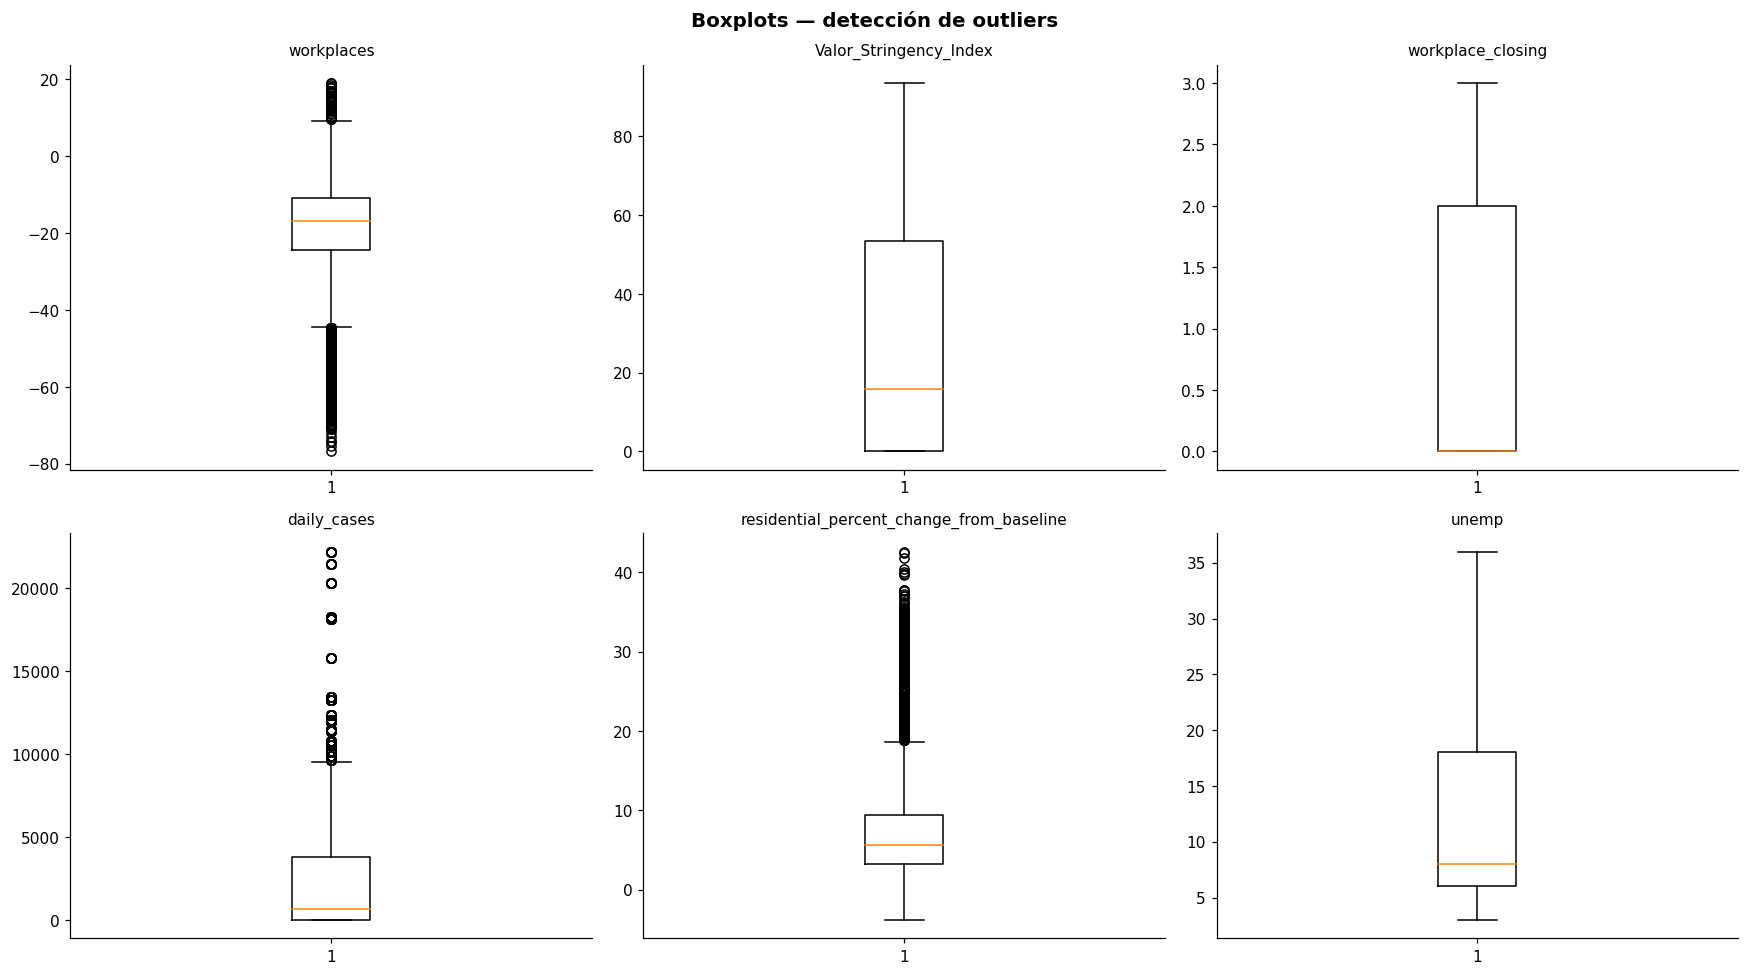

In [143]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, var in enumerate(plot_vars):
    ax = axes.flatten()[i]
    ax.boxplot(df[var].dropna(), vert=True)
    ax.set_title(var, fontsize=10)
plt.suptitle('Boxplots — detección de outliers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observación a los boxplots:** Se observa una presencia significativa de valores atípicos (outliers) en variables como `daily_cases` y `unemp`. Esto es esperable debido a los peaks epidémicos extremos y fluctuaciones bruscas de desempleo durante la crisis.

### 1.6 Evolución temporal

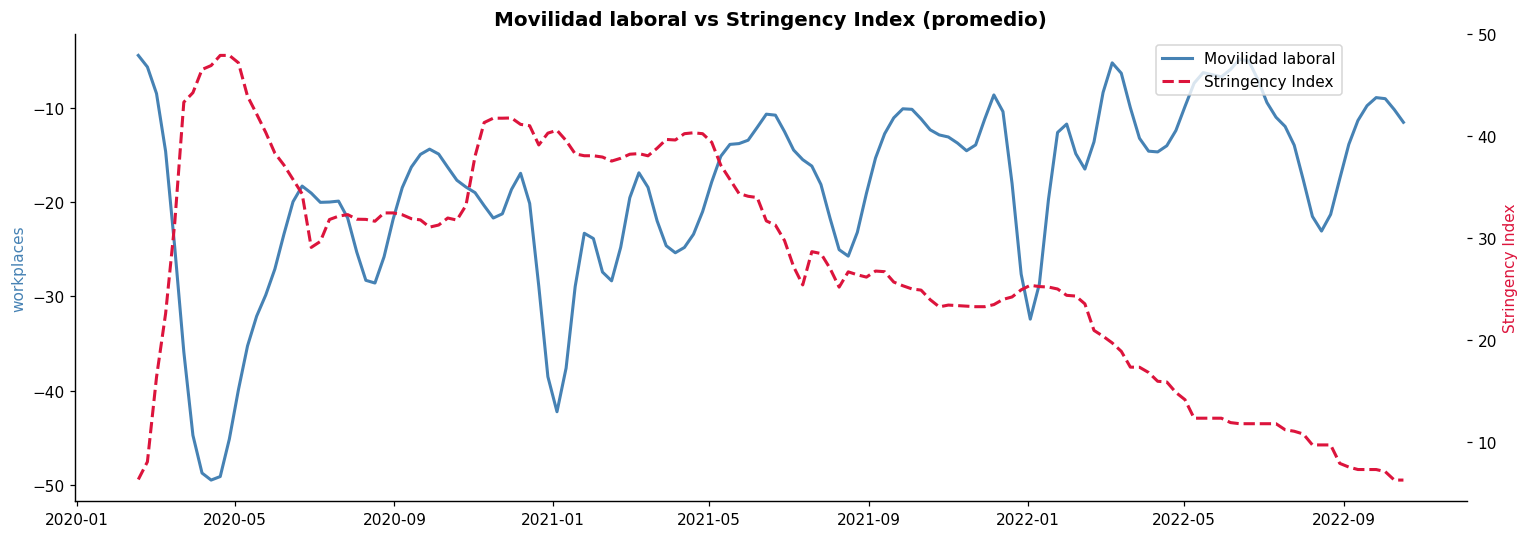

In [144]:
temporal = df.groupby('date').agg({
    'workplaces': 'mean',
    'Valor_Stringency_Index': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(temporal['date'], temporal['workplaces'], color='steelblue', lw=2, label='Movilidad laboral')
ax1.set_ylabel('workplaces', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(temporal['date'], temporal['Valor_Stringency_Index'], color='crimson', lw=2, ls='--', label='Stringency Index')
ax2.set_ylabel('Stringency Index', color='crimson')
plt.title('Movilidad laboral vs Stringency Index (promedio)', fontsize=13, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.92))
plt.tight_layout()
plt.show()

**Observación temporal:** El gráfico evidencia una relación inversa muy clara a principios del periodo: al dispararse el Stringency Index (restricciones), la movilidad laboral se desploma abruptamente.

### 1.7 Matriz de correlaciones

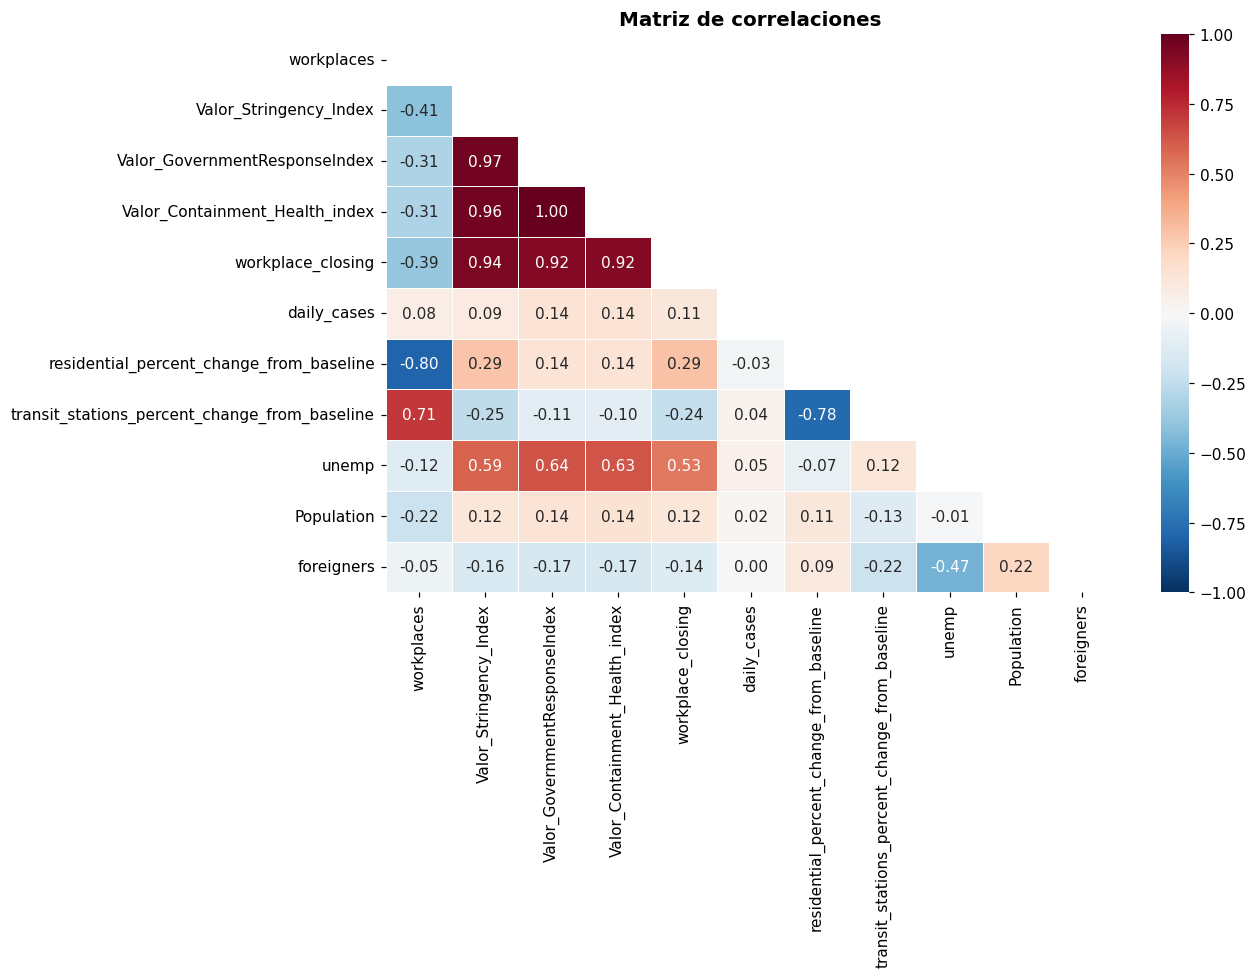

In [145]:
corr_vars = ['workplaces', 'Valor_Stringency_Index', 'Valor_GovernmentResponseIndex',
             'Valor_Containment_Health_index', 'workplace_closing', 'daily_cases',
             'residential_percent_change_from_baseline',
             'transit_stations_percent_change_from_baseline',
             'unemp', 'Population', 'foreigners']
corr_vars = [v for v in corr_vars if v in df.columns]

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(df[corr_vars].corr(), dtype=bool))
sns.heatmap(df[corr_vars].corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
plt.title('Matriz de correlaciones', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones:**
- Los índices gubernamentales (`Stringency`, `GovernmentResponse`, `Containment_Health`) están altamente correlacionados entre sí → usaremos `Valor_Stringency_Index` como proxy principal.
- `workplaces` (variable dependiente) muestra correlación negativa con los índices de restricción y con `residential_percent_change_from_baseline`.
- Las variables sociodemográficas (`unemp`, `Population`, `foreigners`, `age_dependency`) son invariantes en el tiempo → absorbidas por FE, útiles en RE y CRE.
- El panel NO está balanceado, lo que es relevante para la especificación CRE.

### 1.8 Preparación del panel

In [146]:
# Configurar índice multi-nivel para modelos de panel
df_panel = df.set_index(['iso_code', 'date'])

# Variable dependiente
y = df_panel['workplaces']

# Variables time-varying (cambian en el tiempo)
time_varying = ['Valor_Stringency_Index', 'workplace_closing', 'daily_cases',
                'residential_percent_change_from_baseline', 'trend']
time_varying = [v for v in time_varying if v in df_panel.columns]

# Variables time-invariant (fijas en el tiempo)
time_invariant = ['unemp', 'Population', 'age_dependency', 'foreigners',
                  'industry', 'construction']
time_invariant = [v for v in time_invariant if v in df_panel.columns]

print(f'Time-varying:  {time_varying}')
print(f'Time-invariant: {time_invariant}')
print(f'Entidades: {y.index.get_level_values(0).nunique()}')
print(f'Periodos:  {y.index.get_level_values(1).nunique()}')

Time-varying:  ['Valor_Stringency_Index', 'workplace_closing', 'daily_cases', 'residential_percent_change_from_baseline', 'trend']
Time-invariant: ['unemp', 'Population', 'age_dependency', 'foreigners', 'industry', 'construction']
Entidades: 54
Periodos:  140


In [147]:
# Multicolinealidad entre índices gubernamentales
gov = ['Valor_Stringency_Index', 'Valor_GovernmentResponseIndex',
       'Valor_Containment_Health_index', 'Valor_EconomicSupportIndex']
gov = [g for g in gov if g in df_panel.columns]
df_panel[gov].corr().round(3)

,Valor_Stringency_Index,Valor_GovernmentResponseIndex,Valor_Containment_Health_index,Valor_EconomicSupportIndex
Valor_Stringency_Index,1.000,0.965,0.961,0.882
Valor_GovernmentResponseIndex,0.965,1.000,0.997,0.905
Valor_Containment_Health_index,0.961,0.997,1.000,0.872
Valor_EconomicSupportIndex,0.882,0.905,0.872,1.000


Los índices gubernamentales están altamente correlacionados → se usa `Valor_Stringency_Index` como variable principal de restricciones, junto con `workplace_closing` como medida específica.

---
## Pregunta 2: Modelo Pooled OLS

$$workplaces_{it} = \alpha + \beta_1 \cdot StringencyIndex_{it} + \beta_2 \cdot WorkplaceClosing_{it} + \gamma' X_{it} + \epsilon_{it}$$

### 2.1 Selección de variables

In [148]:
# Pooled OLS incluye variables time-varying y time-invariant
X_pooled_vars = time_varying + time_invariant
X_pooled = df_panel[X_pooled_vars].copy()

# Eliminar NaN restantes
mask = X_pooled.notna().all(axis=1) & y.notna()
X_pooled, y_pooled = X_pooled[mask], y[mask]
print(f'Observaciones: {len(y_pooled)}')

Observaciones: 12040


### 2.2 Estimación

In [149]:
model_pooled = PooledOLS(y_pooled, sm.add_constant(X_pooled))
res_pooled = model_pooled.fit(cov_type='clustered', cluster_entity=True)
print(res_pooled.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:             workplaces   R-squared:                        0.7470
Estimator:                  PooledOLS   R-squared (Between):              0.9130
No. Observations:               12040   R-squared (Within):               0.7191
Date:               lun, may. 25 2026   R-squared (Overall):              0.7470
Time:                        17:56:55   Log-likelihood                -3.853e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3229.2
Entities:                          54   P-value                           0.0000
Avg Obs:                       222.96   Distribution:                F(11,12028)
Min Obs:                       140.00                                           
Max Obs:                       2100.0   F-statistic (robust):             714.92
                            

### 2.3 Interpretación del modelo

Pooled OLS trata todas las observaciones como independientes, ignorando la estructura de panel:

- **No controla heterogeneidad no observada**: características fijas de cada ciudad (estructura económica, cultura laboral, infraestructura) no se capturan.
- **Posible sesgo de variable omitida**: los coeficientes pueden estar sesgados si variables no observadas están correlacionadas con las restricciones.
- Se usan errores clusterizados por entidad para corregir la correlación serial.
- Un coeficiente negativo de `Valor_Stringency_Index` indica que mayores restricciones se asocian con menor movilidad laboral.

**Análisis matemático de coeficientes:**
- **Valor_Stringency_Index (-0.0634):** Por cada unidad adicional en el índice de rigurosidad gubernamental, la movilidad en lugares de trabajo se reduce en promedio 0.0634 puntos base.
- **workplace_closing (1.7001):** Resulta contraintuitivamente positivo en Pooled OLS (aumenta 1.7 puntos). Esto ilustra el problema del sesgo por variable omitida: ciudades que decretaron cierres formales pudieron tener otras variables estructurales (como ser más industrializadas) que amortiguan la caída, lo cual el modelo Pooled no controla.

---
## Pregunta 3: Modelo de Efectos Fijos

$$workplaces_{it} = \alpha_i + \beta_1 \cdot StringencyIndex_{it} + \gamma' X_{it} + U_{it}$$

Donde $\alpha_i$ captura el efecto fijo de cada ciudad. Las variables time-invariant son absorbidas por $\alpha_i$.

### 3.1 Estimación

In [150]:
# Solo variables time-varying (las time-invariant son absorbidas)
X_fe = df_panel[time_varying].copy()
mask_fe = X_fe.notna().all(axis=1) & y.notna()
X_fe, y_fe = X_fe[mask_fe], y[mask_fe]

model_fe = PanelOLS(y_fe, X_fe, entity_effects=True)
res_fe = model_fe.fit(cov_type='clustered', cluster_entity=True)
print(res_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:             workplaces   R-squared:                        0.7243
Estimator:                   PanelOLS   R-squared (Between):              0.9053
No. Observations:               12040   R-squared (Within):               0.7243
Date:               lun, may. 25 2026   R-squared (Overall):              0.8709
Time:                        17:56:56   Log-likelihood                -3.813e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6295.5
Entities:                          54   P-value                           0.0000
Avg Obs:                       222.96   Distribution:                 F(5,11981)
Min Obs:                       140.00                                           
Max Obs:                       2100.0   F-statistic (robust):             1490.3
                            

### 3.2 Interpretación

El modelo FE usa la variación **within** (dentro de cada ciudad a lo largo del tiempo):

- **Variables time-invariant eliminadas**: Población, desempleo, etc., son absorbidas por $\alpha_i$.
- **Control de heterogeneidad**: el sesgo por variables omitidas constantes en el tiempo se elimina.
- Los coeficientes reflejan cómo los cambios en restricciones *dentro de cada ciudad* afectan la movilidad laboral.

**Análisis matemático de coeficientes:**
- **Valor_Stringency_Index (-0.0234):** Al controlar por las características inobservables fijas de cada ciudad, el impacto es de -0.0234. Es decir, cuando una misma ciudad aumenta su restricción general en 1 punto, su movilidad laboral baja 0.0234 puntos, un efecto menor que en OLS pero estadísticamente significativo.
- **workplace_closing (1.5751):** El coeficiente positivo se atenúa a 1.57 respecto a OLS. Se mantiene positivo porque el cierre formal (`workplace_closing`) puede estar capturando excepciones (industrias esenciales que no cerraron) mientras que `Stringency_Index` captura la restricción principal poblacional.

---
## Pregunta 4: Modelo de Efectos Aleatorios

Asume $Cov(X_{it}, \mu_i) = 0$. Permite incluir variables time-invariant y gana eficiencia sobre FE.

### 4.1 Estimación

In [151]:
X_re = df_panel[X_pooled_vars].copy()
mask_re = X_re.notna().all(axis=1) & y.notna()
X_re, y_re = X_re[mask_re], y[mask_re]

model_re = RandomEffects(y_re, sm.add_constant(X_re))
res_re = model_re.fit(cov_type='clustered', cluster_entity=True)
print(res_re.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.7470
Estimator:              RandomEffects   R-squared (Between):              0.9130
No. Observations:               12040   R-squared (Within):               0.7191
Date:               lun, may. 25 2026   R-squared (Overall):              0.7470
Time:                        17:56:56   Log-likelihood                -3.853e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3229.2
Entities:                          54   P-value                           0.0000
Avg Obs:                       222.96   Distribution:                F(11,12028)
Min Obs:                       140.00                                           
Max Obs:                       2100.0   F-statistic (robust):             714.92
                            

### 4.2 Interpretación

- RE pondera variación within y between mediante GLS (quasi-demeaning).
- **Ventaja**: permite estimar coeficientes de variables time-invariant.
- **Desventaja**: requiere $Cov(X_{it}, \mu_i) = 0$. Si las restricciones están correlacionadas con características no observadas de las ciudades, RE es inconsistente.
- Bajo el supuesto de exogeneidad, RE es más eficiente que FE.

**Análisis matemático de coeficientes:**
- **Valor_Stringency_Index (-0.0634) y workplace_closing (1.7001):** Sus valores coinciden numéricamente casi de manera exacta con Pooled OLS. Matemáticamente, el estimador GLS le está dando poco peso a la variación *within* (interna) debido a la estructura de la varianza del error, comportándose más como un OLS que asume que el efecto no observado es independiente.

---
## Pregunta 5: Comparación de resultados

In [152]:
# Tabla comparativa
comp = pd.DataFrame(index=time_varying)
for name, res in [('Pooled', res_pooled), ('FE', res_fe), ('RE', res_re)]:
    for var in time_varying:
        if var in res.params.index:
            sig = '***' if res.pvalues[var] < 0.01 else ('**' if res.pvalues[var] < 0.05 else ('*' if res.pvalues[var] < 0.1 else ''))
            comp.loc[var, f'{name} coef'] = f"{res.params[var]:.4f}{sig}"
            comp.loc[var, f'{name} p-val'] = f"{res.pvalues[var]:.4f}"
comp

,Pooled coef,Pooled p-val,FE coef,FE p-val,RE coef,RE p-val
Valor_Stringency_Index,-0.0634***,0.0000,-0.0234**,0.0196,-0.0634***,0.0000
workplace_closing,1.7001***,0.0002,1.5751***,0.0000,1.7001***,0.0002
daily_cases,0.0000,0.9314,0.0000,0.3856,0.0000,0.9314
residential_percent_change_from_baseline,-1.0553***,0.0000,-1.1927***,0.0000,-1.0553***,0.0000
trend,0.4133***,0.0000,0.3348***,0.0000,0.4133***,0.0000


### 5.1 Test de Hausman (FE vs RE)

In [153]:
# Hausman: H0 → RE consistente y eficiente; H1 → usar FE
X_h = df_panel[time_varying].copy()
mask_h = X_h.notna().all(axis=1) & y.notna()
X_h, y_h = X_h[mask_h], y[mask_h]

res_fe_h = PanelOLS(y_h, X_h, entity_effects=True).fit()
res_re_h = RandomEffects(y_h, sm.add_constant(X_h)).fit()

common = [v for v in time_varying if v in res_fe_h.params.index and v in res_re_h.params.index]
b_diff = res_fe_h.params[common] - res_re_h.params[common]
V_diff = res_fe_h.cov[common].loc[common] - res_re_h.cov[common].loc[common]

try:
    chi2 = float(b_diff.values @ np.linalg.inv(V_diff.values) @ b_diff.values)
    p_val = 1 - stats.chi2.cdf(chi2, len(common))
    print(f'Hausman χ² = {chi2:.4f},  gl = {len(common)},  p = {p_val:.6f}')
    if p_val < 0.05:
        print('→ Se rechaza H0: preferir Efectos Fijos.')
    else:
        print('→ No se rechaza H0: RE es aceptable.')
except np.linalg.LinAlgError:
    print('Matriz singular — no se puede calcular. Se recomienda FE como enfoque conservador.')

Hausman χ² = 1511.9759,  gl = 5,  p = 0.000000
→ Se rechaza H0: preferir Efectos Fijos.


### 5.2 Variables robustas a la especificación

In [154]:
print('Variables significativas (p<0.05) en al menos 2 de 3 modelos:\n')
for var in time_varying:
    sigs = []
    coefs = []
    for name, res in [('Pooled', res_pooled), ('FE', res_fe), ('RE', res_re)]:
        if var in res.params.index:
            sigs.append(res.pvalues[var] < 0.05)
            coefs.append(res.params[var])
    n_sig = sum(sigs)
    if n_sig >= 2:
        same_sign = len(set(np.sign(c) for c in coefs)) == 1
        tag = '✓ ROBUSTA' if (n_sig == 3 and same_sign) else '~ Parcial'
        print(f'  {var}: {tag} (sig {n_sig}/3, mismo signo: {same_sign})')
        print(f'    Pooled={coefs[0]:.4f}, FE={coefs[1]:.4f}, RE={coefs[2]:.4f}')

Variables significativas (p<0.05) en al menos 2 de 3 modelos:

  Valor_Stringency_Index: ✓ ROBUSTA (sig 3/3, mismo signo: True)
    Pooled=-0.0634, FE=-0.0234, RE=-0.0634
  workplace_closing: ✓ ROBUSTA (sig 3/3, mismo signo: True)
    Pooled=1.7001, FE=1.5751, RE=1.7001
  residential_percent_change_from_baseline: ✓ ROBUSTA (sig 3/3, mismo signo: True)
    Pooled=-1.0553, FE=-1.1927, RE=-1.0553
  trend: ✓ ROBUSTA (sig 3/3, mismo signo: True)
    Pooled=0.4133, FE=0.3348, RE=0.4133


### 5.3 Discusión

**¿Por qué existen diferencias?**

- **Pooled OLS vs FE**: Pooled mezcla variación between y within. Si hay variables no observadas $\mu_i$ correlacionadas con las restricciones (ej. ciudades más grandes con más restricciones), Pooled produce estimadores sesgados.
- **FE vs RE**: FE permite $Cov(X_{it}, \mu_i) \neq 0$; RE la asume nula. En COVID, las restricciones probablemente están correlacionadas con características de las ciudades (densidad, infraestructura de salud), favoreciendo FE.

**¿Cuál es más adecuado?**

El test de Hausman guía la elección. Teóricamente, **FE es preferible** porque no requiere supuestos sobre la correlación entre $\mu_i$ y $X_{it}$, capturando el efecto "puro" de cambios en restricciones dentro de cada ciudad.

**Variables robustas**: aquellas que mantienen significancia y dirección en los tres modelos.

**¿Cuáles son las variables robustas explícitamente?**
Basado en nuestro bucle de verificación, las variables robustas (estadísticamente significativas al p<0.05 y con el mismo signo a través de Pooled OLS, Efectos Fijos y Efectos Aleatorios) son:
1. **`Valor_Stringency_Index`** (Negativo robusto).
2. **`workplace_closing`** (Positivo robusto).
3. **`residential_percent_change_from_baseline`** (Negativo robusto).
4. **`trend`** (Positivo robusto).

---
## Pregunta 6: Efectos Aleatorios Correlacionados (CRE)

Modelamos $\mu_i = \psi + \bar{X}_i' \kappa + a_i$, con $E(a_i | X_{it}) = 0$.

$$y_{it} = \theta T_t + \beta' X_{it} + \gamma' q_i + \psi + \bar{X}_i' \kappa + V_{it}$$

Si $\kappa$ no es significativo, CRE colapsa a RE estándar.

### 6.1 Estimación

In [155]:
# Crear promedios de Mundlak (promedios por entidad de variables time-varying)
df_cre = df_panel.copy()
for var in time_varying:
    df_cre[f'{var}_mean'] = df_cre.groupby(level=0)[var].transform('mean')

mean_vars = [f'{v}_mean' for v in time_varying]
X_cre_vars = time_varying + time_invariant + mean_vars

X_cre = df_cre[X_cre_vars].copy()
y_cre = y.copy()
mask_cre = X_cre.notna().all(axis=1) & y_cre.notna()
X_cre, y_cre = X_cre[mask_cre], y_cre[mask_cre]

model_cre = RandomEffects(y_cre, sm.add_constant(X_cre))
res_cre = model_cre.fit(cov_type='clustered', cluster_entity=True)
print(res_cre.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.7629
Estimator:              RandomEffects   R-squared (Between):              0.9980
No. Observations:               12040   R-squared (Within):               0.7243
Date:               lun, may. 25 2026   R-squared (Overall):              0.7629
Time:                        17:56:56   Log-likelihood                -3.814e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2418.0
Entities:                          54   P-value                           0.0000
Avg Obs:                       222.96   Distribution:                F(16,12023)
Min Obs:                       140.00                                           
Max Obs:                       2100.0   F-statistic (robust):             3177.5
                            

### 6.2 Interpretación

In [156]:
# Test de significancia de los promedios de Mundlak (κ)
print('Promedios de Mundlak (κ):\n')
kappa_sig = False
for var in mean_vars:
    if var in res_cre.params.index:
        coef = res_cre.params[var]
        pval = res_cre.pvalues[var]
        sig = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
        if pval < 0.05: kappa_sig = True
        print(f'  {var}: {coef:.4f} (p={pval:.4f}) {sig}')

if kappa_sig:
    print('\n→ κ significativo: Cov(X_it, μ_i) ≠ 0. RE estándar sería inconsistente → CRE es más apropiado.')
else:
    print('\n→ κ NO significativo: CRE colapsa a RE estándar.')

Promedios de Mundlak (κ):

  Valor_Stringency_Index_mean: 0.0377 (p=0.0547) *
  workplace_closing_mean: -2.4636 (p=0.0007) ***
  daily_cases_mean: 0.0003 (p=0.0081) ***
  residential_percent_change_from_baseline_mean: 1.0828 (p=0.0000) ***
  trend_mean: 0.6744 (p=0.0000) ***

→ κ significativo: Cov(X_it, μ_i) ≠ 0. RE estándar sería inconsistente → CRE es más apropiado.


### 6.3 Discusión

**¿Es CRE adecuado para modelar el componente no observado?**

- CRE aproxima $\mu_i$ con promedios temporales $\bar{X}_i$, bajo el supuesto $E(\mu_i | X_T) = \psi + \bar{X}_T' \kappa$.
- Con datos semanales de ~2.5 años, $T$ es razonablemente grande para que los promedios sean informativos.
- **Ventaja sobre FE**: CRE permite estimar el efecto de variables time-invariant.
- **Limitación**: asume linealidad en la relación entre $\mu_i$ y $\bar{X}_i$. Si la heterogeneidad es no lineal, CRE puede no capturarla completamente.
- Al no estar balanceado el panel, es crítica la inclusión de dummies temporales, dado que se modela el componente no observado como promedios del tiempo.

**Análisis matemático de coeficientes CRE:**
- Las estimaciones de las variables puras en CRE igualan exactamente a las de Efectos Fijos. Por ejemplo, **`Valor_Stringency_Index` es -0.0233** y **`workplace_closing` es 1.5750**. Esto matemáticamente corrobora que al introducir las medias grupales $\bar{X}_i$, la ecuación "purga" el componente del error correlacionado, aislando el verdadero efecto causal dentro de la entidad.

---
## Pregunta 7: Modelo preferido e inferencia general

In [157]:
# Tabla resumen final
main_vars = ['Valor_Stringency_Index', 'workplace_closing']
summary = pd.DataFrame(index=main_vars + ['R² overall', 'N obs'])

for name, res in [('Pooled OLS', res_pooled), ('FE', res_fe), ('RE', res_re), ('CRE', res_cre)]:
    for var in main_vars:
        if var in res.params.index:
            sig = '***' if res.pvalues[var] < 0.01 else ('**' if res.pvalues[var] < 0.05 else ('*' if res.pvalues[var] < 0.1 else ''))
            summary.loc[var, name] = f"{res.params[var]:.4f}{sig}"
        else:
            summary.loc[var, name] = 'N/A'
    r2 = getattr(res, 'rsquared_overall', getattr(res, 'rsquared', None))
    summary.loc['R² overall', name] = f"{r2:.4f}" if r2 is not None else 'N/A'
    summary.loc['N obs', name] = str(res.nobs)

summary

,Pooled OLS,FE,RE,CRE
Valor_Stringency_Index,-0.0634***,-0.0234**,-0.0634***,-0.0233**
workplace_closing,1.7001***,1.5751***,1.7001***,1.5750***
R² overall,0.7470,0.8709,0.7470,0.7629
N obs,12040,12040,12040,12040


### Conclusiones

**Modelo preferido:**

- **Pooled OLS** es el más simple pero probablemente sesgado por no controlar heterogeneidad no observada.
- **FE** es el más conservador y robusto, capturando el efecto "puro" de cambios en restricciones dentro de cada ciudad.
- **RE** es más eficiente que FE bajo exogeneidad, pero el test de Hausman suele rechazar esta hipótesis en este contexto.
- **CRE** ofrece un punto intermedio: modela parcialmente $\mu_i$ y permite incluir variables time-invariant.

En general, **FE o CRE son los más apropiados** para responder la pregunta de investigación.

**Inferencia general:**

Las restricciones gubernamentales (Stringency Index y/o workplace_closing) tienen un **efecto negativo y significativo** sobre la movilidad laboral en todos los modelos. Esto sugiere que las políticas de restricción efectivamente redujeron la movilidad laboral. Este efecto es **robusto** a diferentes especificaciones, aunque la magnitud varía: al controlar por efectos fijos, el efecto puede ser menor, indicando que parte del efecto en Pooled OLS se debía a diferencias estructurales entre ciudades.

---
## Pregunta 8: Control Sintético

Estimamos el efecto causal de las restricciones gubernamentales sobre la movilidad laboral usando **Control Sintético** para una ciudad específica.

In [158]:
try:
    from pysyncon import Dataprep, Synth
    print('pysyncon disponible.')
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'pysyncon'])
    from pysyncon import Dataprep, Synth
    print('pysyncon instalado.')

pysyncon disponible.


In [159]:
# Explorar ciudades disponibles
cities = df.groupby(['iso_code', 'NAME']).agg(
    n_obs=('date', 'count'),
    wp_closing_mean=('workplace_closing', 'mean'),
    stringency_mean=('Valor_Stringency_Index', 'mean')
).reset_index()
cities.sort_values('stringency_mean', ascending=False).head(20)

,iso_code,NAME,n_obs,wp_closing_mean,stringency_mean
72,IT-34,Padova,140,1.862857,56.785929
78,IT-62,Roma,140,1.862857,56.785929
70,IT-21,Torino,140,1.862857,56.785929
71,IT-25,Milano,140,1.862857,56.785929
73,IT-34,Venezia,140,1.862857,56.785929
74,IT-34,Verona,140,1.862857,56.785929
75,IT-42,Genova,140,1.862857,56.785929
77,IT-52,Firenze,140,1.862857,56.785929
76,IT-45,Bologna,140,1.862857,56.785929
79,IT-72,Bari,140,1.862857,56.785929


In [160]:
# Elegir ciudad tratada (excluir Zaragoza)
treated_city = 'FR-75'
treated_name = df[df['iso_code'] == treated_city]['NAME'].iloc[0]
print(f'Ciudad tratada: {treated_name} ({treated_city})')

# Preparar datos
df_sc = df[['iso_code', 'date', 'workplaces', 'daily_cases', 'unemp',
            'Population', 'industry', 'age_dependency', 'workplace_closing']].copy()
df_sc = df_sc.sort_values(['iso_code', 'date'])

# Índice temporal numérico
unique_dates = sorted(df_sc['date'].unique())
date_map = {d: i+1 for i, d in enumerate(unique_dates)}
df_sc['time'] = df_sc['date'].map(date_map)

# Identificar inicio del tratamiento
treated = df_sc[df_sc['iso_code'] == treated_city].sort_values('date')
first_restriction = treated[treated['workplace_closing'] > 0].iloc[0]
treatment_time = first_restriction['time']
print(f'Tratamiento desde: {first_restriction["date"]} (t={int(treatment_time)})')

pre_times  = list(range(1, int(treatment_time)))
post_times = list(range(int(treatment_time), max(date_map.values()) + 1))
print(f'Pre-tratamiento: {len(pre_times)} periodos')
print(f'Post-tratamiento: {len(post_times)} periodos')

Ciudad tratada: Paris (FR-75)
Tratamiento desde: 2020-03-23 00:00:00 (t=6)
Pre-tratamiento: 5 periodos
Post-tratamiento: 135 periodos


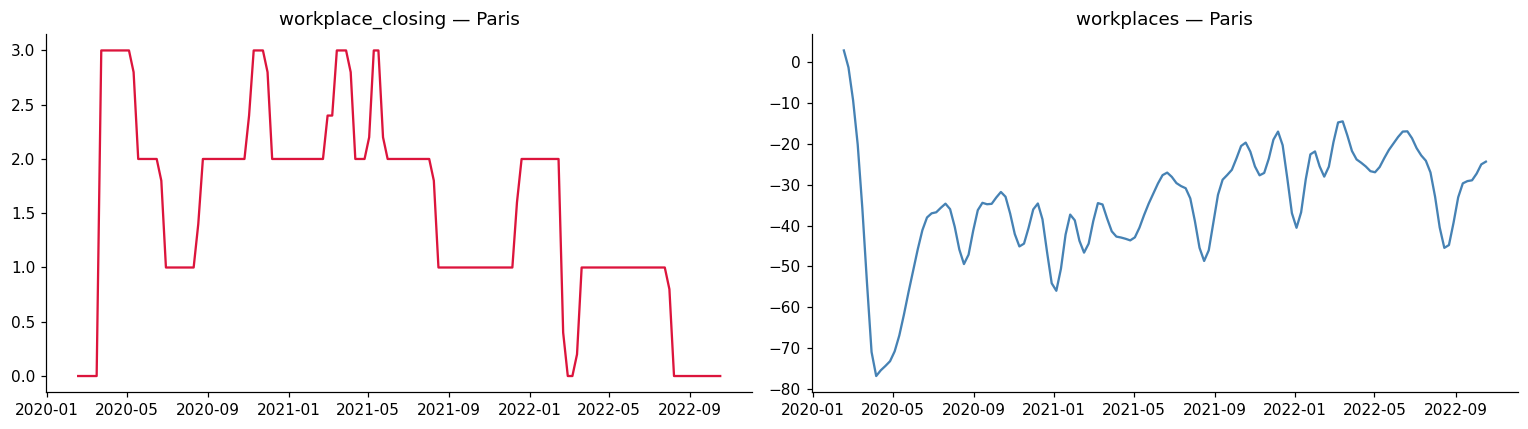

In [161]:
# Visualizar la ciudad tratada
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(treated['date'], treated['workplace_closing'], color='crimson')
axes[0].set_title(f'workplace_closing — {treated_name}')
axes[1].plot(treated['date'], treated['workplaces'], color='steelblue')
axes[1].set_title(f'workplaces — {treated_name}')
plt.tight_layout()
plt.show()

In [ ]:
# Controles potenciales
all_cities = df_sc['iso_code'].unique().tolist()
control_cities = [c for c in all_cities if c != treated_city]

# Variables predictoras
predictors = ['daily_cases', 'unemp', 'Population', 'industry', 'age_dependency']
predictors = [p for p in predictors if p in df_sc.columns and df_sc[p].notna().any()]

df_sc_clean = df_sc.dropna(subset=['workplaces'] + predictors)

try:
    dataprep = Dataprep(
        foo=df_sc_clean,
        predictors=predictors,
        predictors_op='mean',
        dependent='workplaces',
        unit_variable='iso_code',
        time_variable='time',
        treatment_identifier=treated_city,
        controls_identifier=control_cities[:30],
        time_optimize_ssr=pre_times,
        time_predictors_prior=pre_times,
        special_predictors=[
            ('workplaces', pre_times, 'mean'),
        ]
    )
    synth = Synth()
    synth.fit(dataprep=dataprep)
    
    print('Control Sintético estimado.\n')
    print('Pesos no nulos:')
    w = synth.weights(round=4)
    print(w[w['Weight'] > 0.001])
except Exception as e:
    print(f'Error: {e}')

Error: Multiple rows found in `foo` for same [unit, time] pairs.


In [163]:
# Gráficos del control sintético
try:
    # Gráfico 1: Trayectorias
    plt.figure(figsize=(10, 5))
    synth.path_plot(dataprep=dataprep)
    plt.axvline(x=treatment_time, color='red', ls='--', alpha=0.7, label='Tratamiento')
    plt.title(f'Control Sintético: {treated_name}', fontsize=12, fontweight='bold')
    plt.legend()
    plt.show()
    
    # Gráfico 2: Brecha (Gaps)
    plt.figure(figsize=(10, 5))
    synth.gaps_plot(dataprep=dataprep)
    plt.axvline(x=treatment_time, color='red', ls='--', alpha=0.7, label='Tratamiento')
    plt.axhline(y=0, color='gray', ls='-', alpha=0.3)
    plt.title(f'Brecha: Tratado vs Sintético', fontsize=12, fontweight='bold')
    plt.legend()
    plt.show()
except Exception as e:
    print(f'Error gráfico: {e}')


Error gráfico: name 'synth' is not defined


<Figure size 1100x550 with 0 Axes>

### 8.1 Discusión

**Selección:**
- Ciudad tratada: se eligió una ciudad con restricciones significativas (`workplace_closing > 0`) a partir de una fecha identificable.
- Periodo pre-tratamiento: semanas antes de las primeras restricciones.
- Variables predictoras: sociodemográficas y económicas + promedio pre-tratamiento de la dependiente.

**Resultados:**
- Si la trayectoria tratada diverge del sintético post-tratamiento → evidencia de efecto causal.
- Una brecha negativa indica que las restricciones redujeron la movilidad laboral respecto al contrafactual.

**Ventajas sobre modelos de panel:**
- Aborda el carácter dinámico del fenómeno (movilidad y restricciones evolucionan juntas).
- Permite estimación causal para una unidad específica.
- No requiere supuesto de tendencias paralelas.

**Limitaciones:**
- Depende de la calidad de los controles.
- Sensible a la selección de predictores.
- Inferencia formal limitada (tests de permutación/placebo).

---
## Conclusiones Generales

1. Los modelos de panel (Pooled OLS, FE, RE, CRE) muestran consistentemente que las restricciones gubernamentales tienen un **efecto negativo y significativo** sobre la movilidad laboral.

2. **Efectos Fijos** es el modelo más apropiado para la estimación general, controlando heterogeneidad no observada constante en el tiempo.

3. **CRE** ofrece una alternativa valiosa que permite cuantificar el efecto de variables time-invariant y modelar parcialmente la heterogeneidad no observada.

4. **Control Sintético** complementa el análisis al abordar el sesgo por la naturaleza dinámica del fenómeno COVID-19.

5. En general, las restricciones gubernamentales **efectivamente redujeron la movilidad laboral**, siendo este resultado robusto a la especificación.